In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn import metrics
import xgboost as xgb
import time
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv("data.csv")
data

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
0,2022-01-28 00:00:00,67.253113,10.185185,121.003326,576.604736,20.849820
1,2022-01-28 00:01:00,67.253113,10.185185,121.003326,576.604736,20.849820
2,2022-01-28 00:02:00,67.253113,10.185185,121.003326,576.604736,20.849820
3,2022-01-28 00:03:00,67.253113,10.185185,121.003326,576.604736,20.849820
4,2022-01-28 00:04:00,67.253113,10.185185,121.003326,576.604736,20.849820
...,...,...,...,...,...,...
101066,2022-10-20 16:57:00,NaN,NaN,NaN,507.211636,19.755739
101067,2022-10-20 16:58:00,NaN,NaN,NaN,511.160186,19.755739
101068,2022-10-20 16:59:00,NaN,NaN,NaN,509.005283,19.755739
101069,2022-10-20 17:00:00,NaN,NaN,NaN,510.360491,19.755739


In [3]:
data['Time'] = pd.to_datetime(data['Time'], format="%Y/%m/%d %H:%M:%S")
data.dtypes

Time                datetime64[ns]
COURANT ValueY             float64
DEBIT EAU ValueY           float64
SOLIDE ValueY              float64
PUISSANCE ValueY           float64
refus_tamis                float64
dtype: object

Split dep_test with 100 observations

In [4]:
dep_test = data.sample(100)
dep_test

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
18357,2022-08-23 19:55:00,67.631975,12.023269,112.666669,582.509843,18.015507
91232,2022-10-13 21:03:00,59.247052,9.361497,109.176372,508.389800,20.857343
28119,2022-08-30 14:37:00,69.648133,10.117514,109.946120,599.363227,19.992224
38457,2022-09-06 18:55:00,70.253034,13.217779,116.695136,600.064244,18.665855
9115,2022-02-03 07:55:00,68.003983,9.615765,115.789569,583.178607,23.742697
...,...,...,...,...,...,...
62887,2022-09-24 04:14:00,62.764762,10.279691,109.729981,536.991348,18.029353
57915,2022-09-20 17:22:00,63.689948,11.512470,114.452659,545.823868,22.603776
83288,2022-10-08 08:37:00,61.061308,12.026536,117.047783,521.661389,22.736659
82411,2022-10-07 18:00:00,61.226231,14.677839,164.591033,525.313429,17.205847


In [5]:
data.drop(dep_test.index, inplace=True)

In [6]:
data.shape

(100971, 6)

In [7]:
X = data[["Time","COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
X

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
0,2022-01-28 00:00:00,67.253113,10.185185,121.003326,20.849820
1,2022-01-28 00:01:00,67.253113,10.185185,121.003326,20.849820
2,2022-01-28 00:02:00,67.253113,10.185185,121.003326,20.849820
3,2022-01-28 00:03:00,67.253113,10.185185,121.003326,20.849820
4,2022-01-28 00:04:00,67.253113,10.185185,121.003326,20.849820
...,...,...,...,...,...
101066,2022-10-20 16:57:00,NaN,NaN,NaN,19.755739
101067,2022-10-20 16:58:00,NaN,NaN,NaN,19.755739
101068,2022-10-20 16:59:00,NaN,NaN,NaN,19.755739
101069,2022-10-20 17:00:00,NaN,NaN,NaN,19.755739


In [8]:
y = data[["Time","PUISSANCE ValueY"]]
y

,Time,PUISSANCE ValueY
0,2022-01-28 00:00:00,576.604736
1,2022-01-28 00:01:00,576.604736
2,2022-01-28 00:02:00,576.604736
3,2022-01-28 00:03:00,576.604736
4,2022-01-28 00:04:00,576.604736
...,...,...
101066,2022-10-20 16:57:00,507.211636
101067,2022-10-20 16:58:00,511.160186
101068,2022-10-20 16:59:00,509.005283
101069,2022-10-20 17:00:00,510.360491


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
X_train

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
16202,2022-02-16 09:15:00,65.930695,10.309910,118.371160,19.930912
69480,2022-09-28 18:07:00,63.421051,10.918249,134.494652,18.198089
86720,2022-10-10 17:49:00,60.067483,9.763525,114.297774,20.874999
97482,2022-10-18 05:13:00,60.529700,10.095486,114.636682,21.997273
14212,2022-02-15 00:05:00,66.835510,9.563079,117.946757,22.158927
...,...,...,...,...,...
6272,2022-02-01 08:32:00,63.861196,9.107952,109.516963,27.598417
54945,2022-09-18 15:41:00,64.402196,10.859445,113.383049,21.232549
76896,2022-10-03 22:03:00,61.833918,8.230613,92.094967,18.734397
861,2022-01-28 14:21:00,64.324417,10.323471,119.338047,20.849820


In [11]:
y_train

,Time,PUISSANCE ValueY
16202,2022-02-16 09:15:00,564.984110
69480,2022-09-28 18:07:00,544.336052
86720,2022-10-10 17:49:00,514.312148
97482,2022-10-18 05:13:00,517.526945
14212,2022-02-15 00:05:00,574.295915
...,...,...
6272,2022-02-01 08:32:00,543.161717
54945,2022-09-18 15:41:00,553.283489
76896,2022-10-03 22:03:00,531.442927
861,2022-01-28 14:21:00,556.592670


In [12]:
(X_train.isna().sum()/X_train.shape[0]).sort_values(ascending=True)

Time                0.000000
refus_tamis         0.000000
COURANT ValueY      0.001288
DEBIT EAU ValueY    0.002844
SOLIDE ValueY       0.011772
dtype: float64

In [13]:
X_train_1 = X_train[["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
X_test_1 = X_test[["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
y_train_1 = y_train[["PUISSANCE ValueY"]]
y_test_1 = y_test[["PUISSANCE ValueY"]]

Remplacer les NaNs par le moyen 

In [14]:
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
X_train_1 = pd.DataFrame(imputer.fit_transform(X_train_1), columns=["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"],index=X_train_1.index)
X_train_1

,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
16202,65.930695,10.309910,118.371160,19.930912
69480,63.421051,10.918249,134.494652,18.198089
86720,60.067483,9.763525,114.297774,20.874999
97482,60.529700,10.095486,114.636682,21.997273
14212,66.835510,9.563079,117.946757,22.158927
...,...,...,...,...
6272,63.861196,9.107952,109.516963,27.598417
54945,64.402196,10.859445,113.383049,21.232549
76896,61.833918,8.230613,92.094967,18.734397
861,64.324417,10.323471,119.338047,20.849820


In [15]:
(X_train_1.isna().sum()/X_train_1.shape[0]).sort_values(ascending=True)

COURANT ValueY      0.0
DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
refus_tamis         0.0
dtype: float64

In [16]:
X_test_1 = pd.DataFrame(imputer.transform(X_test_1), columns=["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"],index=X_test_1.index)
X_test_1

,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
20661,72.913640,13.696027,0.000000,20.218690
67091,65.051685,11.618060,113.967002,20.732685
75914,0.000000,2.222759,0.000000,18.734397
34004,0.000000,0.000000,0.000000,22.282692
29168,68.019868,9.268126,109.778985,18.017168
...,...,...,...,...
28750,68.311144,9.683020,110.376064,18.017168
100867,61.323629,9.663267,111.835997,19.755739
81083,61.762883,9.895483,108.374811,16.236483
18630,69.198123,12.763800,112.825637,17.766038


In [17]:
(X_test_1.isna().sum()/X_test_1.shape[0]).sort_values(ascending=True)

COURANT ValueY      0.0
DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
refus_tamis         0.0
dtype: float64

In [18]:
dep_test_X = dep_test[["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
dep_test_Y = dep_test[["PUISSANCE ValueY"]]

In [19]:
dep_test_X = pd.DataFrame(imputer.transform(dep_test_X), columns=["COURANT ValueY","DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"],index=dep_test_X.index)
dep_test_X

,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
18357,67.631975,12.023269,112.666669,18.015507
91232,59.247052,9.361497,109.176372,20.857343
28119,69.648133,10.117514,109.946120,19.992224
38457,70.253034,13.217779,116.695136,18.665855
9115,68.003983,9.615765,115.789569,23.742697
...,...,...,...,...
62887,62.764762,10.279691,109.729981,18.029353
57915,63.689948,11.512470,114.452659,22.603776
83288,61.061308,12.026536,117.047783,22.736659
82411,61.226231,14.677839,164.591033,17.205847


In [20]:
(dep_test_X.isna().sum()/dep_test_X.shape[0]).sort_values(ascending=True)

COURANT ValueY      0.0
DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
refus_tamis         0.0
dtype: float64

Polynomial regression
KNN Regression
SVM
XGBoost

Linear Regression

In [83]:
lin_reg = LinearRegression()
Start_Time = time.time()
lin_reg.fit(X_train_1, y_train_1)
Execution_Time_lin_reg = time.time() - Start_Time

In [22]:
lin_reg.score(X_train_1, y_train_1)

0.9806276427100513

In [23]:
lin_reg.score(X_test_1, y_test_1)

0.9809107592698468

Polynomial Regression

In [24]:
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X_train_1)
pol_reg = LinearRegression()

Start_Time = time.time()
pol_reg.fit(X_poly, y_train_1)
Execution_Time_poly_reg = time.time() - Start_Time

In [25]:
pol_reg.score(X_poly, y_train_1)

0.9832508984428435

In [26]:
X_test_poly = poly_reg.transform(X_test_1)

In [27]:
pol_reg.score(X_test_poly, y_test_1)

0.982499329480396

KNN Regression

In [28]:
Start_Time = time.time()
knn_model = KNeighborsRegressor(n_neighbors=5).fit(X_train_1, y_train_1)
Execution_Time_knn = time.time() - Start_Time
score_knn_train = knn_model.score(X_train_1, y_train_1)
score_knn_train

0.9943076262786205

In [29]:
score_knn_test = knn_model.score(X_test_1, y_test_1)
score_knn_test

0.9917289074290212

SVR

In [65]:
regressor = SVR(kernel = 'rbf')
start_time = time.time()
regressor.fit(X_train_1, y_train_1)
Execution_Time_SVR = time.time() - start_time
regressor.score(X_test_1, y_test_1)

c:\Users\Amine DD\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.9754108356901559

XGBoost

In [30]:
model = xgb.XGBRegressor()
Start_Time = time.time()
model.fit(X_train_1, y_train_1)
Execution_Time_xgboost = time.time() - Start_Time
print(model)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0, gpu_id=-1,
             grow_policy='depthwise', importance_type=None,
             interaction_constraints='', learning_rate=0.300000012, max_bin=256,
             max_cat_threshold=64, max_cat_to_onehot=4, max_delta_step=0,
             max_depth=6, max_leaves=0, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, ...)


In [31]:
model.score(X_train_1, y_train_1)

0.9996649569865979

In [32]:
model.score(X_test_1, y_test_1)

0.9923334156343375

Evaluation par RMSE de ces 4 algorithme

In [33]:
print("Linear Regression: ", np.sqrt(metrics.mean_squared_error(y_test_1,lin_reg.predict(X_test_1))))
print("Polynomial Regression: ", np.sqrt(metrics.mean_squared_error(y_test_1,pol_reg.predict(poly_reg.transform(X_test_1)))))
print("KNN Regression: ", np.sqrt(metrics.mean_squared_error(y_test_1,knn_model.predict(X_test_1))))
print("XGBoost Regression: ", np.sqrt(metrics.mean_squared_error(y_test_1,model.predict(X_test_1))))

Linear Regression:  20.16648120707032
Polynomial Regression:  19.309149402721225
KNN Regression:  13.274471498368648
XGBoost Regression:  12.780173748997422


prediction for the test sample

In [71]:
Start_time = time.time()
y_predict_dep_test_lin_reg = lin_reg.predict(X_test_1)
lin_reg_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_poly_reg = pol_reg.predict(poly_reg.transform(X_test_1))
poly_reg_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_knn = knn_model.predict(X_test_1)
knn_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_xgboost = model.predict(X_test_1)
xgboost_pred_time = time.time() - Start_time

Compare the performance of models

In [72]:
pd.DataFrame({'MSE':[metrics.mean_squared_error(y_test_1,lin_reg.predict(X_test_1)),metrics.mean_squared_error(y_test_1,pol_reg.predict(poly_reg.transform(X_test_1))),metrics.mean_squared_error(y_test_1,knn_model.predict(X_test_1)),metrics.mean_squared_error(y_test_1,model.predict(X_test_1))],
              'MAE': [metrics.mean_absolute_error(y_test_1,lin_reg.predict(X_test_1)),metrics.mean_absolute_error(y_test_1,pol_reg.predict(poly_reg.transform(X_test_1))),metrics.mean_absolute_error(y_test_1,knn_model.predict(X_test_1)),metrics.mean_absolute_error(y_test_1,model.predict(X_test_1))],
              'R2':[lin_reg.score(X_test_1, y_test_1),pol_reg.score(poly_reg.transform(X_test_1), y_test_1),knn_model.score(X_test_1, y_test_1),model.score(X_test_1, y_test_1)],
              'Time of Execution train (s)':[Execution_Time_lin_reg,Execution_Time_poly_reg,Execution_Time_knn,Execution_Time_xgboost],
              'Time of prediction test (s)':[lin_reg_pred_time,poly_reg_pred_time,knn_pred_time,xgboost_pred_time]}, index=["LinearRegression","PolynomialRegression","KNN","XGBoost"])

,MSE,MAE,R2,Time of Execution train (s),Time of prediction test (s)
LinearRegression,406.686964,2.920546,0.980911,0.012308,0.003278
PolynomialRegression,372.843251,4.441441,0.982499,0.384196,0.070054
KNN,176.211594,2.495767,0.991729,0.121729,0.409966
XGBoost,163.332841,2.181854,0.992333,2.568154,0.022882


Evaluate the model with dep_test sample and plot the result

In [73]:
y_predict_dep_test_lin_reg = lin_reg.predict(dep_test_X)
y_predict_dep_test_poly_reg = pol_reg.predict(poly_reg.transform(dep_test_X))
y_predict_dep_test_knn = knn_model.predict(dep_test_X)
y_predict_dep_test_xgboost = model.predict(dep_test_X)

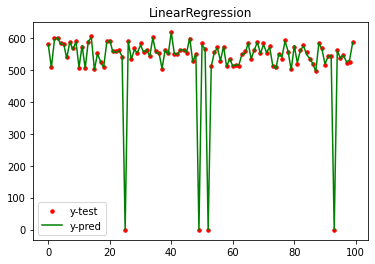

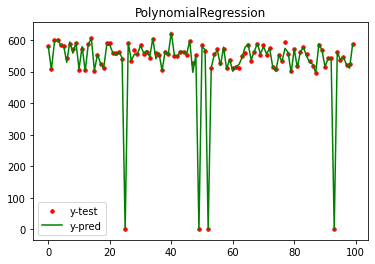

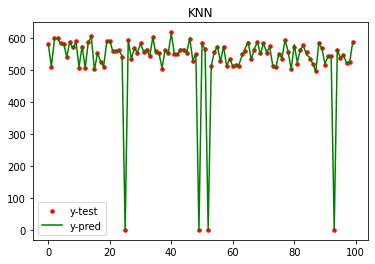

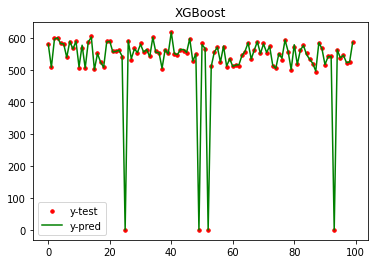

In [81]:
list_prediction = [y_predict_dep_test_lin_reg,y_predict_dep_test_poly_reg,y_predict_dep_test_knn,y_predict_dep_test_xgboost]
list_alg = ["LinearRegression","PolynomialRegression","KNN","XGBoost"]
for pred,alg in zip(list_prediction,list_alg):
    x_ax = range(len(dep_test_X))
    plt.scatter(x_ax, dep_test_Y,  s=12, label="y-test",c= "red")
    plt.plot(x_ax, pred, label="y-pred",c = "green")
    plt.legend()
    plt.title(alg)
    plt.show()

ba9i khaass hi ndir des conclusions ela visualisation graphique
ndir chi visualisation ba9i nfsser elach khdit l mean fdkchi pre-processing ola hi dik l3ba nta3 std tkon kbira ela mean hi bchwiya 10%
